# **Task 1** - Data Analysis
As I am new to a lot tools and directions that I have not encounted before, I decided to follow closely the draft solutions document

In [1]:
# Import libraries
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt

In [2]:
# Read files
transactionData = pd.read_excel("QVI_transaction_data.xlsx")
customerData = pd.read_csv("QVI_purchase_behaviour.csv")

## **1) Dataset Previews**

Firstly, we glance through the content of 2 acquired datasets to understand what is in the datasets, what data can I use to analyze for the client's needs.

In [3]:
# transactionData file preview
transactionData.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,43390,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,43599,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,43605,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,43329,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,43330,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8


In [5]:
# customerData file preview
customerData.head()

,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,YOUNG SINGLES/COUPLES,Premium
1,1002,YOUNG SINGLES/COUPLES,Mainstream
2,1003,YOUNG FAMILIES,Budget
3,1004,OLDER SINGLES/COUPLES,Mainstream
4,1005,MIDAGE SINGLES/COUPLES,Mainstream


In [6]:
transactionData.describe()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_QTY,TOT_SALES
count,264836.000000,264836.00000,2.648360e+05,2.648360e+05,264836.000000,264836.000000,264836.000000
mean,43464.036260,135.08011,1.355495e+05,1.351583e+05,56.583157,1.907309,7.304200
std,105.389282,76.78418,8.057998e+04,7.813303e+04,32.826638,0.643654,3.083226
min,43282.000000,1.00000,1.000000e+03,1.000000e+00,1.000000,1.000000,1.500000
25%,43373.000000,70.00000,7.002100e+04,6.760150e+04,28.000000,2.000000,5.400000
50%,43464.000000,130.00000,1.303575e+05,1.351375e+05,56.000000,2.000000,7.400000
75%,43555.000000,203.00000,2.030942e+05,2.027012e+05,85.000000,2.000000,9.200000
max,43646.000000,272.00000,2.373711e+06,2.415841e+06,114.000000,200.000000,650.000000


In [10]:
transactionData["STORE_NBR"].nunique()

272

## **2) Data Cleaning**

In [7]:
# Change DATE format
transactionData['DATE'] = pd.to_datetime(transactionData['DATE'], unit='D', origin='1899-12-30')
transactionData.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8


In [8]:
transactionData['PROD_NAME'].describe()

count                                     264836
unique                                       114
top       Kettle Mozzarella   Basil & Pesto 175g
freq                                        3304
Name: PROD_NAME, dtype: object

Salsa is not a part of our analyzing objective so I decide to remove any salsa purchases

In [9]:
# Extract out all salsa purchases in the dataset
transactionData = transactionData[~transactionData['PROD_NAME'].str.lower().str.contains('salsa')]
#transactionData['PROD_NAME'][transactionData['PROD_NAME'].str.lower().str.contains('chip') == False].unique()

In [10]:
# Common keywords in product names
podNames = transactionData['PROD_NAME'].dropna().str.split().explode().str.lower()
pNames_no_digits = podNames[~podNames.str.contains(r'\d')]
pNames_clean = pNames_no_digits[pNames_no_digits.str.match(r'^[a-zA-Z]+$')]

pNames_clean.value_counts().head(20)


PROD_NAME
chips       49770
kettle      41288
salt        27976
cheese      27890
smiths      27390
pringles    25102
crinkle     22490
corn        22063
doritos     22041
original    21560
cut         19284
chip        18645
chicken     15407
sea         14145
thins       14075
sour        13882
crisps      12607
vinegar     12402
chilli      12389
rrd         11894
Name: count, dtype: int64

In [11]:
# Check if there is null values in the dataset
transactionData.isnull().sum()

DATE              0
STORE_NBR         0
LYLTY_CARD_NBR    0
TXN_ID            0
PROD_NBR          0
PROD_NAME         0
PROD_QTY          0
TOT_SALES         0
dtype: int64

We can see that there are 2 transactions with the quantity of 200, both are from the same customer, which make them outliners compared to the rest of the dataset. So removing this customer's transactions is needed

In [12]:
transactionData.describe()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_QTY,TOT_SALES
count,246742,246742.000000,2.467420e+05,2.467420e+05,246742.000000,246742.000000,246742.000000
mean,2018-12-30 01:19:01.211467520,135.051098,1.355310e+05,1.351311e+05,56.351789,1.908062,7.321322
min,2018-07-01 00:00:00,1.000000,1.000000e+03,1.000000e+00,1.000000,1.000000,1.700000
25%,2018-09-30 00:00:00,70.000000,7.001500e+04,6.756925e+04,26.000000,2.000000,5.800000
50%,2018-12-30 00:00:00,130.000000,1.303670e+05,1.351830e+05,53.000000,2.000000,7.400000
75%,2019-03-31 00:00:00,203.000000,2.030840e+05,2.026538e+05,87.000000,2.000000,8.800000
max,2019-06-30 00:00:00,272.000000,2.373711e+06,2.415841e+06,114.000000,200.000000,650.000000
std,NaN,76.787096,8.071528e+04,7.814772e+04,33.695428,0.659831,3.077828


In [13]:
transactionData[transactionData['PROD_QTY'] == 200]

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
69762,2018-08-19,226,226000,226201,4,Dorito Corn Chp Supreme 380g,200,650.0
69763,2019-05-20,226,226000,226210,4,Dorito Corn Chp Supreme 380g,200,650.0


In [14]:
transactionData[transactionData['LYLTY_CARD_NBR'] == 226000]

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
69762,2018-08-19,226,226000,226201,4,Dorito Corn Chp Supreme 380g,200,650.0
69763,2019-05-20,226,226000,226210,4,Dorito Corn Chp Supreme 380g,200,650.0


In [15]:
outliner_customer = transactionData[transactionData['PROD_QTY'] == 200]['LYLTY_CARD_NBR'].iloc[0]
transactionData[transactionData['LYLTY_CARD_NBR'] == outliner_customer]

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
69762,2018-08-19,226,226000,226201,4,Dorito Corn Chp Supreme 380g,200,650.0
69763,2019-05-20,226,226000,226210,4,Dorito Corn Chp Supreme 380g,200,650.0


In [16]:
# Remove outliners
transactionData = transactionData[transactionData['LYLTY_CARD_NBR'] != outliner_customer]
transactionData.describe()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_QTY,TOT_SALES
count,246740,246740.000000,2.467400e+05,2.467400e+05,246740.000000,246740.000000,246740.000000
mean,2018-12-30 01:18:58.448569344,135.050361,1.355303e+05,1.351304e+05,56.352213,1.906456,7.316113
min,2018-07-01 00:00:00,1.000000,1.000000e+03,1.000000e+00,1.000000,1.000000,1.700000
25%,2018-09-30 00:00:00,70.000000,7.001500e+04,6.756875e+04,26.000000,2.000000,5.800000
50%,2018-12-30 00:00:00,130.000000,1.303670e+05,1.351815e+05,53.000000,2.000000,7.400000
75%,2019-03-31 00:00:00,203.000000,2.030832e+05,2.026522e+05,87.000000,2.000000,8.800000
max,2019-06-30 00:00:00,272.000000,2.373711e+06,2.415841e+06,114.000000,5.000000,29.500000
std,NaN,76.786971,8.071520e+04,7.814760e+04,33.695235,0.342499,2.474897


In [17]:
# Fill the null value in DATE column with 0.0
transactions_by_day = transactionData.groupby('DATE').size().reset_index(name='count')

date_range = pd.date_range(start='2018-07-01', end='2019-06-30')
all_dates = pd.DataFrame({'DATE': date_range})

full_transactions = all_dates.merge(transactions_by_day, on='DATE', how='left')
full_transactions['count'].fillna(0, inplace=True)

full_transactions[full_transactions['count'] == 0]

,DATE,count
177,2018-12-25,0.0


### Transactions over time plot

In [18]:
# The day with the highest total sales of the year
max_val = full_transactions['count'].max()
max_date = full_transactions.loc[full_transactions['count'].idxmax(), 'DATE']
max_date

Timestamp('2018-12-24 00:00:00')

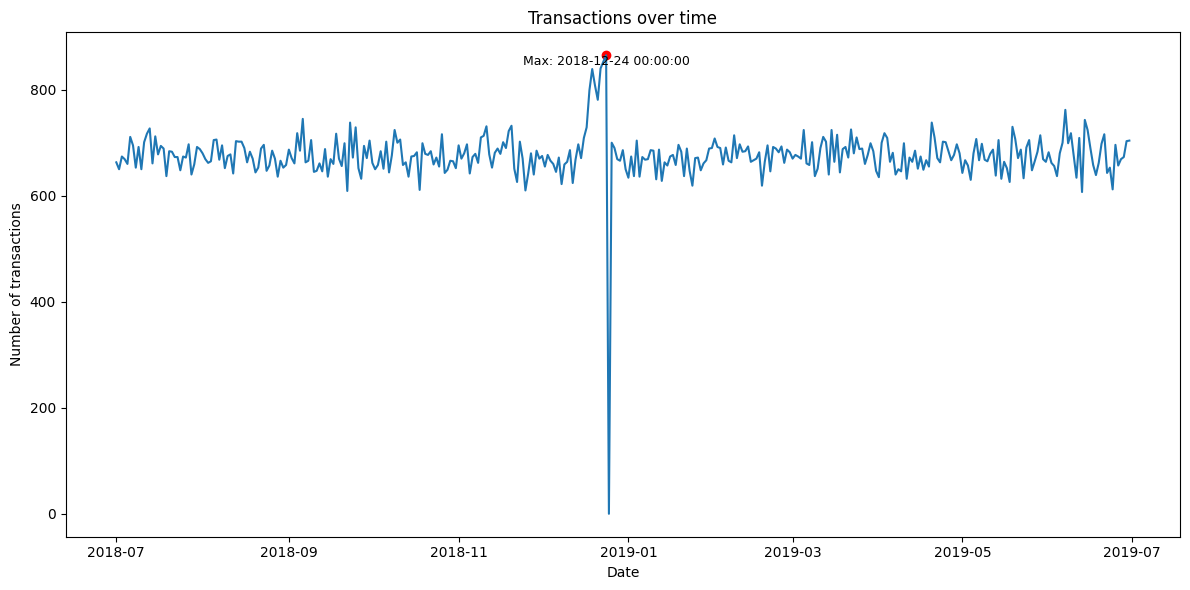

In [19]:
# Transactions in one year

plt.figure(figsize=(12, 6))
plt.plot(full_transactions['DATE'], full_transactions['count'])

plt.scatter([max_date], [max_val], color = 'red')
plt.text(max_date, max_val, f'Max: {max_date}', va='top', ha='center', fontsize=9)

plt.title("Transactions over time")
plt.xlabel("Date")
plt.ylabel("Number of transactions")
plt.tight_layout()
plt.show()


In [20]:
december =  full_transactions[
    (full_transactions['DATE'] >= '2018-12-1') &
    (full_transactions['DATE'] <= '2018-12-31')]

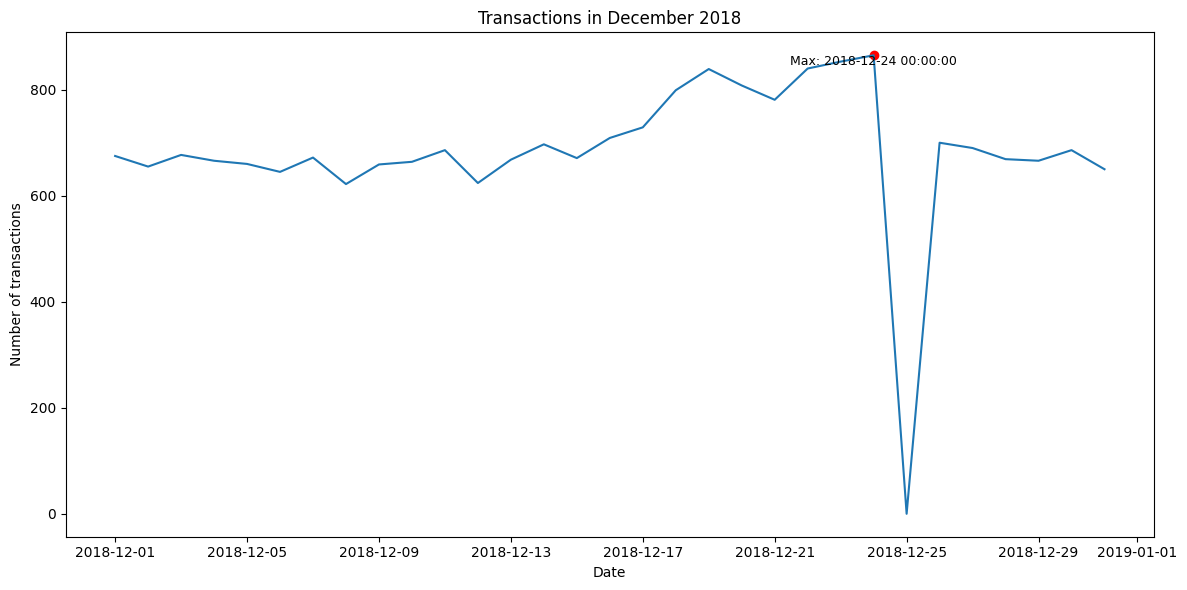

In [21]:
# Transactions in December 
plt.figure(figsize=(12, 6))
plt.plot(december['DATE'], december['count'])

plt.scatter([max_date], [max_val], color = 'red')
plt.text(max_date, max_val, f'Max: {max_date}', va='top', ha='center', fontsize=9)

plt.title("Transactions in December 2018")
plt.xlabel("Date")
plt.ylabel("Number of transactions")
plt.tight_layout()
plt.show()

We can see the chips' sales increased as the demand increased during the holiday season. Then the sales went down to 0 on 25th December as they close the day for Christmas Eve

In [22]:
# Create feature PACK_SIZE
transactionData['PACK_SIZE'] = transactionData['PROD_NAME'].str.extract(r'(\d+)').astype(float)
transactionData['PACK_SIZE'].describe()

count    246740.000000
mean        175.583521
std          59.432118
min          70.000000
25%         150.000000
50%         170.000000
75%         175.000000
max         380.000000
Name: PACK_SIZE, dtype: float64

### Transactions by Pack Sizes

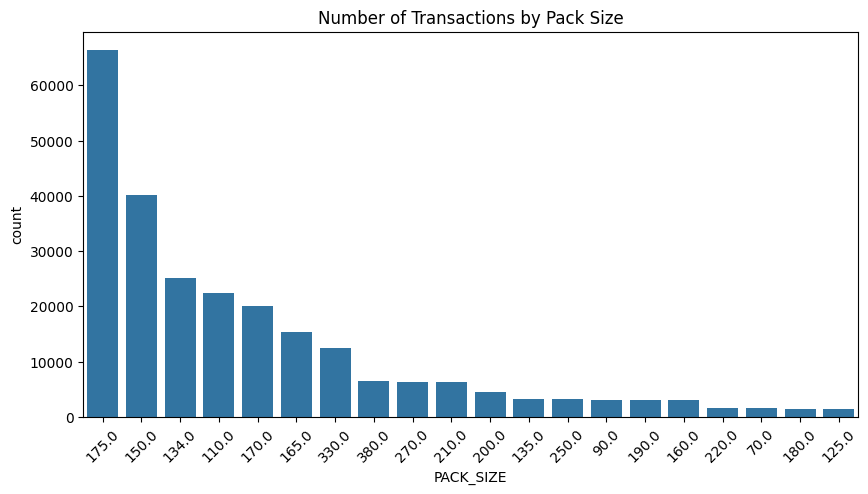

In [23]:
# Number of transactions by PACK_SIZE
plt.figure(figsize=(10, 5))
sb.countplot(data=transactionData, x='PACK_SIZE', order=transactionData['PACK_SIZE'].value_counts().index)
plt.xticks(rotation=45)
plt.title("Number of Transactions by Pack Size")
plt.show()

175g chip packets gain more sales compared to others, with 150g is being in the 2nd highest. In top 10 sizes with most sales, the one from 100-200g are more common

In [24]:
# Extract brand names from product names
transactionData['BRAND'] = transactionData['PROD_NAME'].str.split().str[0]
transactionData['BRAND'].unique()

array(['Natural', 'CCs', 'Smiths', 'Kettle', 'Grain', 'Doritos',
       'Twisties', 'WW', 'Thins', 'Burger', 'NCC', 'Cheezels', 'Infzns',
       'Red', 'Pringles', 'Dorito', 'Infuzions', 'Smith', 'GrnWves',
       'Tyrrells', 'Cobs', 'French', 'RRD', 'Tostitos', 'Cheetos',
       'Woolworths', 'Snbts', 'Sunbites'], dtype=object)

In [25]:
transactionData[transactionData['BRAND'] == "Kettle"]

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,BRAND
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8,150.0,Kettle
11,2018-08-20,8,8294,8221,114,Kettle Sensations Siracha Lime 150g,5,23.0,150.0,Kettle
23,2018-08-19,36,36302,33188,32,Kettle Sea Salt And Vinegar 175g,1,5.4,175.0,Kettle
24,2018-08-15,38,38142,34181,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,2,9.2,150.0,Kettle
27,2019-05-15,41,41423,38393,46,Kettle Original 175g,1,5.4,175.0,Kettle
...,...,...,...,...,...,...,...,...,...,...
264819,2019-06-15,272,272053,269703,46,Kettle Original 175g,2,10.8,175.0,Kettle
264821,2019-05-29,272,272105,269792,32,Kettle Sea Salt And Vinegar 175g,2,10.8,175.0,Kettle
264823,2019-03-17,272,272156,269855,63,Kettle 135g Swt Pot Sea Salt,2,8.4,135.0,Kettle
264824,2019-03-13,272,272193,269906,9,Kettle Tortilla ChpsBtroot&Ricotta 150g,1,4.6,150.0,Kettle


A lot of brand names here is the others but with different ways of naming. So we combine them together

In [26]:
# Combine similar brand names
replacements = {'Red': 'RRD', 
    'Snbts': 'Sunbites',
    'WW': 'Woolworths',
    'Natural': 'NCC',
    'Smith': 'Smiths',
    'Dorito': 'Doritos',
    'Grain': 'GrainWaves',
    'GrnWves': 'GrainWaves',
    'Infzns': 'Infuzions'}

adjusted = transactionData['BRAND']

for old, new in replacements.items():
    adjusted = adjusted.replace(old, new, regex=False)

transactionData['BRAND'] = adjusted
transactionData['BRAND'].unique()


array(['NCC', 'CCs', 'Smiths', 'Kettle', 'GrainWaves', 'Doritos',
       'Twisties', 'Woolworths', 'Thins', 'Burger', 'Cheezels',
       'Infuzions', 'RRD', 'Pringles', 'Tyrrells', 'Cobs', 'French',
       'Tostitos', 'Cheetos', 'Sunbites'], dtype=object)

In [27]:
transactionData['BRAND'].nunique()

20

### Customer Dataset

In [28]:
data = transactionData.merge(customerData, how='left')
data.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,BRAND,LIFESTAGE,PREMIUM_CUSTOMER
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0,175.0,NCC,YOUNG SINGLES/COUPLES,Premium
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3,175.0,CCs,MIDAGE SINGLES/COUPLES,Budget
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9,170.0,Smiths,MIDAGE SINGLES/COUPLES,Budget
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0,175.0,Smiths,MIDAGE SINGLES/COUPLES,Budget
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8,150.0,Kettle,MIDAGE SINGLES/COUPLES,Budget


In [29]:
# Check for null values
data.isnull().sum()

DATE                0
STORE_NBR           0
LYLTY_CARD_NBR      0
TXN_ID              0
PROD_NBR            0
PROD_NAME           0
PROD_QTY            0
TOT_SALES           0
PACK_SIZE           0
BRAND               0
LIFESTAGE           0
PREMIUM_CUSTOMER    0
dtype: int64

In [30]:
# Save the merged dataset
data.to_csv('cleanedData.csv')

## **3) Data Exploration**


### Number of Customer

In [31]:
# Number of customers in each premium level
data.groupby('PREMIUM_CUSTOMER')['LYLTY_CARD_NBR'].nunique().reset_index(name='customer_count')

,PREMIUM_CUSTOMER,customer_count
0,Budget,24006
1,Mainstream,28734
2,Premium,18547


In [32]:
# Number of customers in each lifestyle group
data.groupby('LIFESTAGE')['LYLTY_CARD_NBR'].nunique().reset_index(name='customer_count')


,LIFESTAGE,customer_count
0,MIDAGE SINGLES/COUPLES,7141
1,NEW FAMILIES,2492
2,OLDER FAMILIES,9630
3,OLDER SINGLES/COUPLES,14389
4,RETIREES,14555
5,YOUNG FAMILIES,9036
6,YOUNG SINGLES/COUPLES,14044


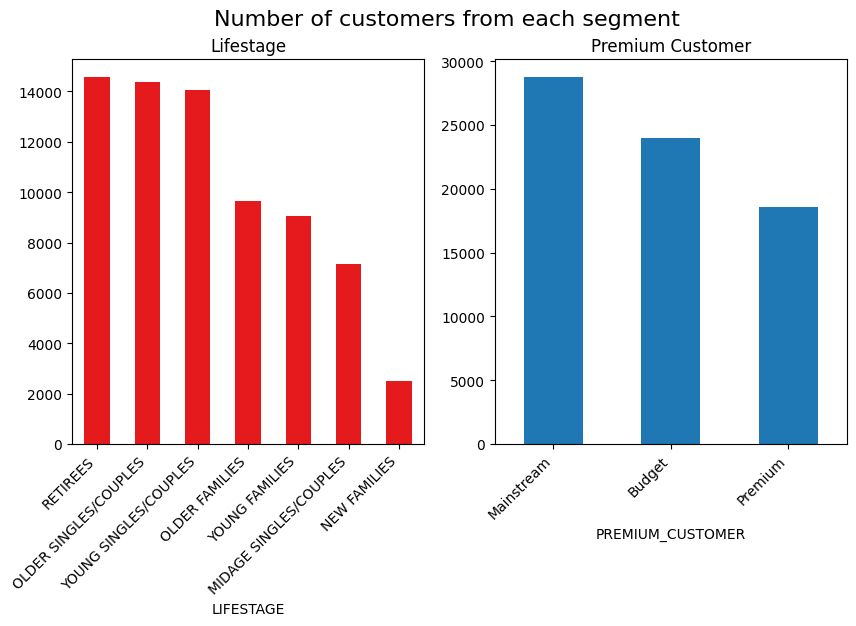

In [84]:
#Number of customers from each segment
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle("Number of customers from each segment", fontsize = 16)

data.groupby('LIFESTAGE')['LYLTY_CARD_NBR'].nunique().sort_values(ascending=False).plot(kind='bar', ax=axes[0], colormap = 'Set1')
axes[0].set_title('Lifestage')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')

data.groupby('PREMIUM_CUSTOMER')['LYLTY_CARD_NBR'].nunique().sort_values(ascending=False).plot(kind='bar', ax=axes[1])
axes[1].set_title('Premium Customer')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right');

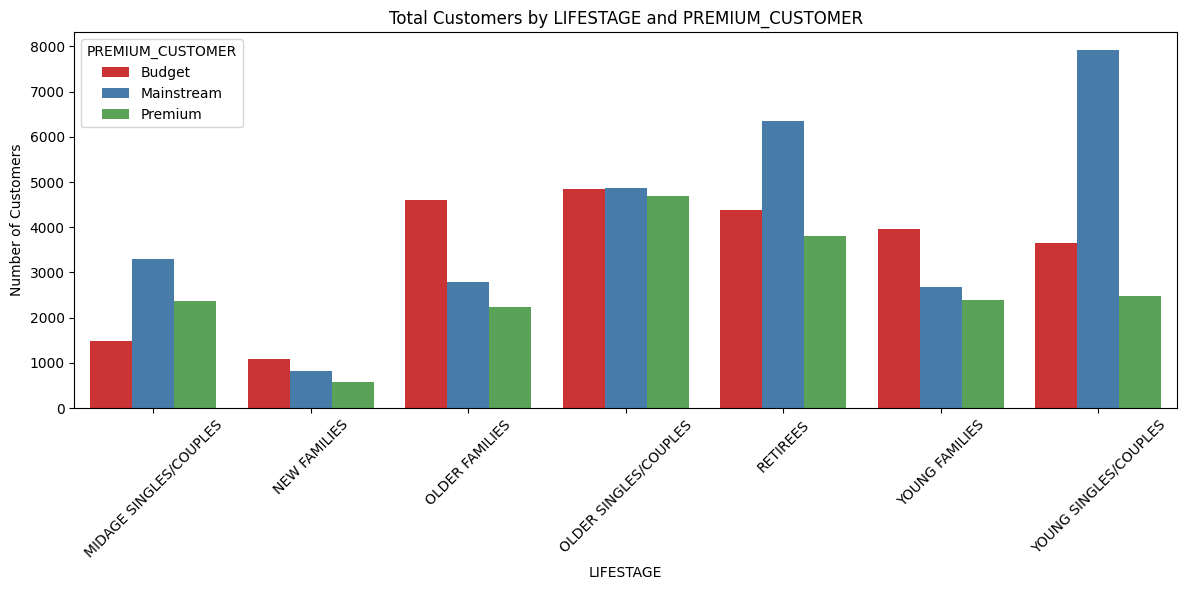

In [34]:
# Total Customers by LIFESTAGE and PREMIUM_CUSTOMER
sales_summary = data.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER'])['LYLTY_CARD_NBR'].nunique().reset_index()
sales_summary

plt.figure(figsize=(12, 6))
sb.barplot(data=sales_summary, x='LIFESTAGE', y='LYLTY_CARD_NBR', hue='PREMIUM_CUSTOMER', palette='Set1')
plt.title("Total Customers by LIFESTAGE and PREMIUM_CUSTOMER")
plt.xticks(rotation=45)
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

From the graph, we can see that the largest customer groups are Mainstream Retirees and Mainstream Young Singles/Couples, while the smallest groups are New Families and Mid-age Singles/Couples.

### Customer Purchase Frequency

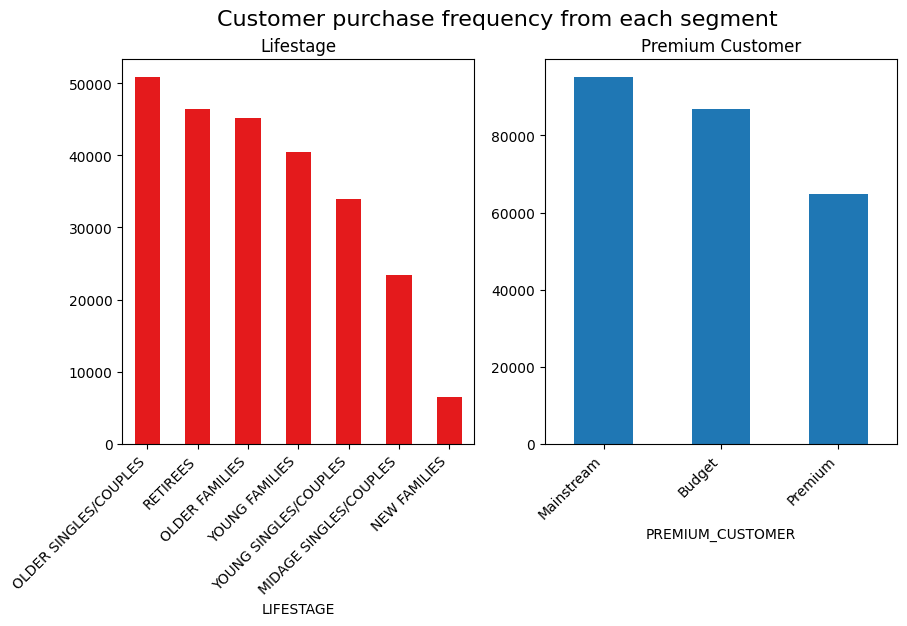

In [35]:
# Customer purchase frequency from each segment
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle("Customer purchase frequency from each segment", fontsize = 16)

data['LIFESTAGE'].value_counts().sort_values(ascending=False).plot(kind='bar', ax=axes[0], colormap = 'Set1')
axes[0].set_title('Lifestage')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')

data['PREMIUM_CUSTOMER'].value_counts().sort_values(ascending=False).plot(kind='bar', ax=axes[1])
axes[1].set_title('Premium Customer')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right');

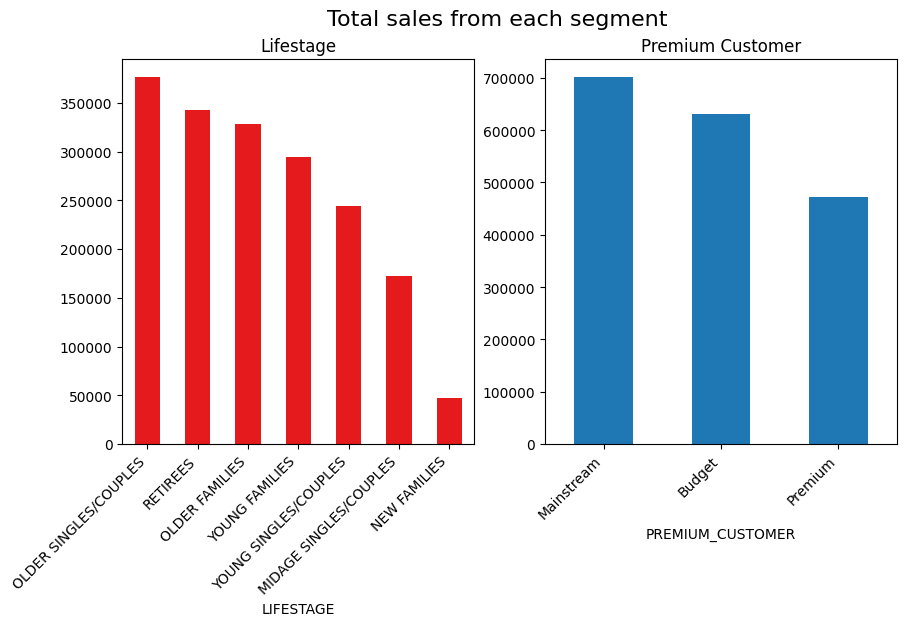

In [36]:
# Total sales from each segment
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle("Total sales from each segment", fontsize = 16)

data.groupby(['LIFESTAGE'])['TOT_SALES'].sum().sort_values(ascending=False).plot(kind = 'bar', ax = axes[0], colormap = 'Set1')
axes[0].set_title('Lifestage')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')

data.groupby(['PREMIUM_CUSTOMER'])['TOT_SALES'].sum().sort_values(ascending=False).plot(kind = 'bar', ax = axes[1])
axes[1].set_title('Premium Customer')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right');

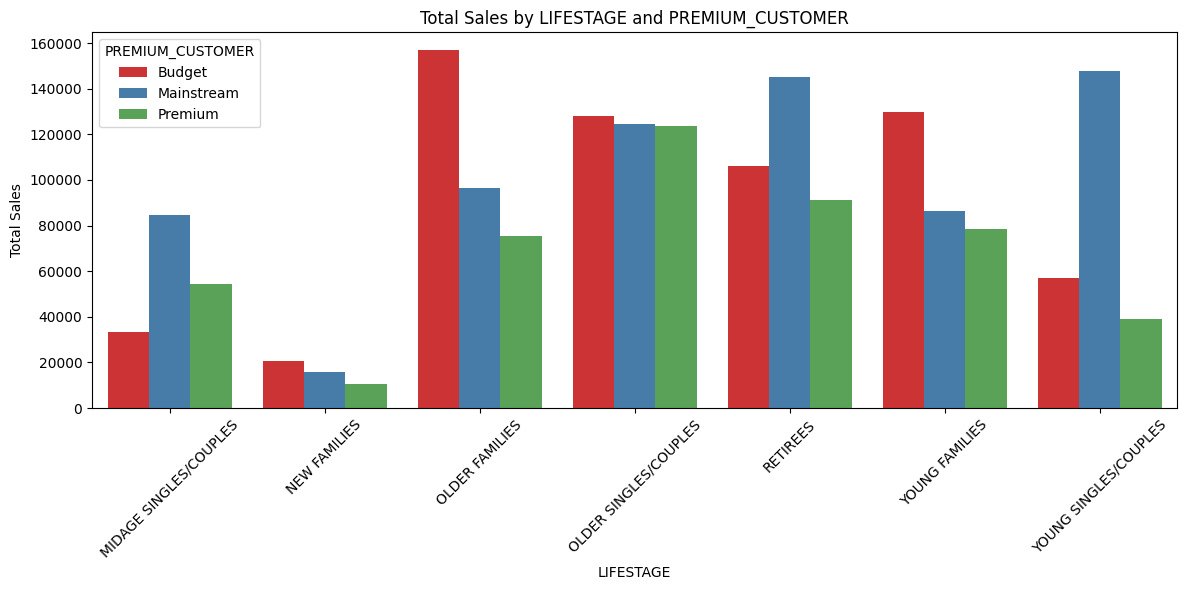

In [37]:
# Total Sales by both segments
sales_summary = data.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER'])['TOT_SALES'].sum().reset_index()
sales_summary

plt.figure(figsize=(12, 6))
sb.barplot(data=sales_summary, x='LIFESTAGE', y='TOT_SALES', hue='PREMIUM_CUSTOMER', palette='Set1')
plt.title("Total Sales by LIFESTAGE and PREMIUM_CUSTOMER")
plt.xticks(rotation=45)
plt.ylabel('Total Sales')
plt.tight_layout()
plt.show()

The customer segment that gains most sales is Budget Older Families, with Mainstream Retirees and Young Singles/ Couples follow behind

### Average Unit per Customer

In [38]:
# Number of purchases per Customer
data.groupby(['LYLTY_CARD_NBR', 'PREMIUM_CUSTOMER', 'LIFESTAGE']).size().reset_index(name='purchase_count')


,LYLTY_CARD_NBR,PREMIUM_CUSTOMER,LIFESTAGE,purchase_count
0,1000,Premium,YOUNG SINGLES/COUPLES,1
1,1002,Mainstream,YOUNG SINGLES/COUPLES,1
2,1003,Budget,YOUNG FAMILIES,2
3,1004,Mainstream,OLDER SINGLES/COUPLES,1
4,1005,Mainstream,MIDAGE SINGLES/COUPLES,1
...,...,...,...,...
71282,2370651,Mainstream,MIDAGE SINGLES/COUPLES,1
71283,2370701,Mainstream,YOUNG FAMILIES,1
71284,2370751,Premium,YOUNG FAMILIES,1
71285,2370961,Budget,OLDER FAMILIES,1


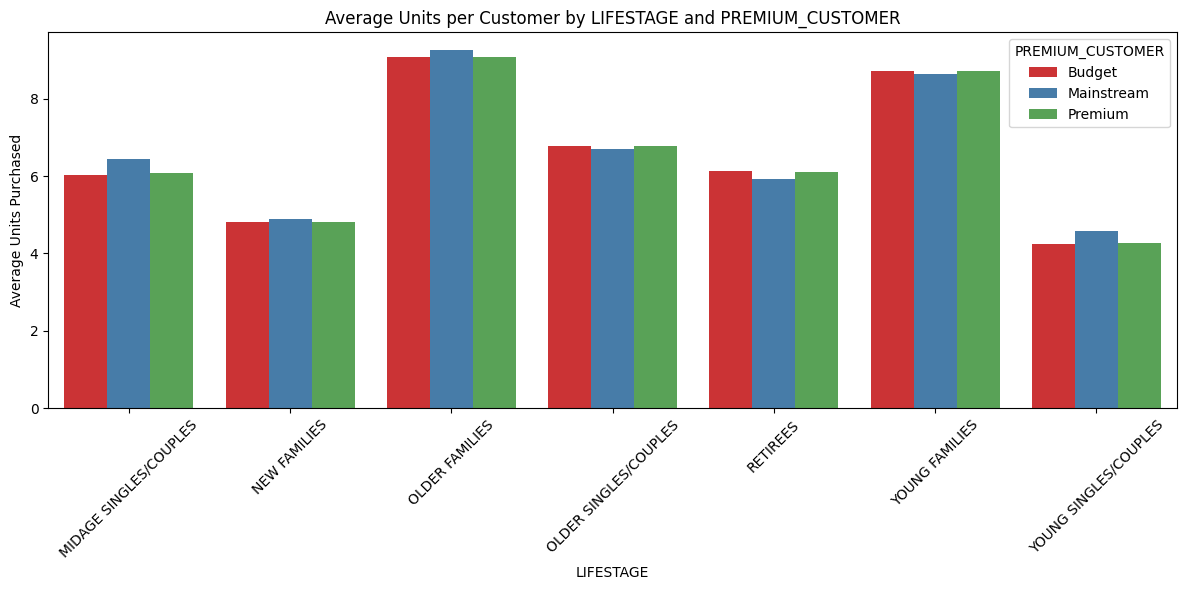

In [39]:
# Average Units per Customer by LIFESTAGE and PREMIUM_CUSTOMER
units_per_customer = data.groupby(['LYLTY_CARD_NBR', 'PREMIUM_CUSTOMER', 'LIFESTAGE'])['PROD_QTY'].sum().reset_index()

avg_units = units_per_customer.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER'])['PROD_QTY'].mean().reset_index()

plt.figure(figsize=(12, 6))
sb.barplot(data=avg_units, x='LIFESTAGE', y='PROD_QTY', hue='PREMIUM_CUSTOMER', palette='Set1')
plt.title('Average Units per Customer by LIFESTAGE and PREMIUM_CUSTOMER')
plt.ylabel('Average Units Purchased')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Two lifestage groups — older families and young families — have made more purchases per person. Among older families, most customers are classified as mainstream, while among young families, more customers are classified as either budget or premium. This suggests that these two groups are more likely to be recurring customers compared to other groups.

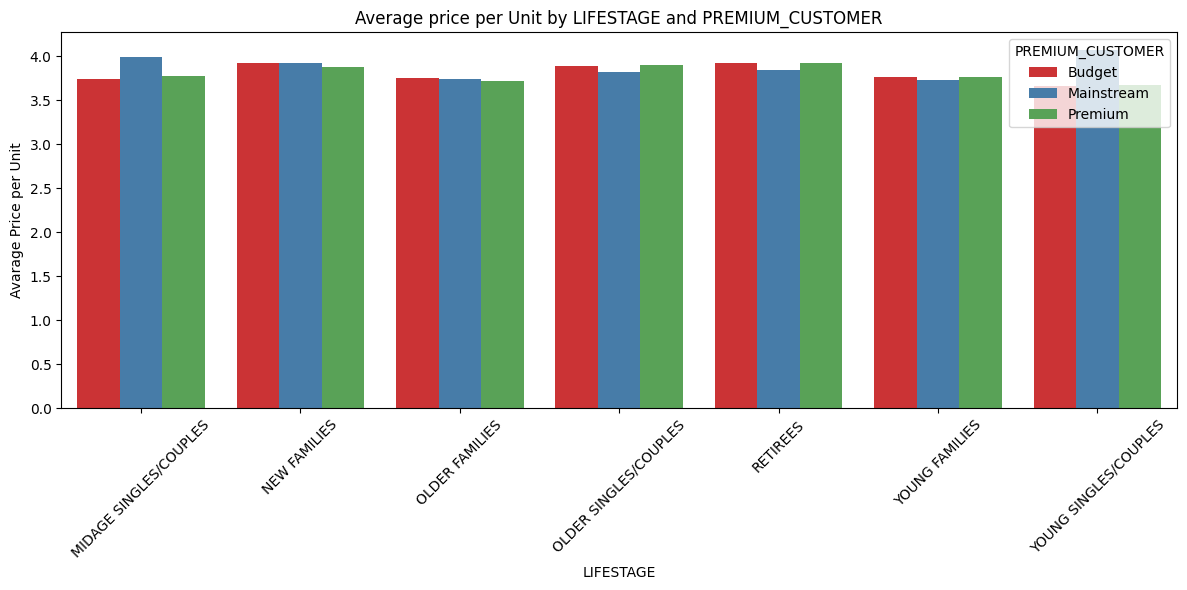

In [40]:
# Average price per Unit by LIFESTAGE and PREMIUM_CUSTOMER
data['UNIT_PRICE'] = data['TOT_SALES'] / data['PROD_QTY']

avg_price = data.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER'])['UNIT_PRICE'].mean().reset_index()

plt.figure(figsize=(12, 6))
sb.barplot(data=avg_price, x='LIFESTAGE', y='UNIT_PRICE', hue='PREMIUM_CUSTOMER', palette='Set1')
plt.title("Average price per Unit by LIFESTAGE and PREMIUM_CUSTOMER")
plt.xticks(rotation=45)
plt.ylabel('Avarage Price per Unit')
plt.tight_layout()
plt.show()


On the other hand, mainstream mid-age singles/couples and young singles/couples spent more money on chips, reflecting their significant contributions to overall sales.

In [41]:
# Number of unit per customer
units_per_customer

,LYLTY_CARD_NBR,PREMIUM_CUSTOMER,LIFESTAGE,PROD_QTY
0,1000,Premium,YOUNG SINGLES/COUPLES,2
1,1002,Mainstream,YOUNG SINGLES/COUPLES,1
2,1003,Budget,YOUNG FAMILIES,2
3,1004,Mainstream,OLDER SINGLES/COUPLES,1
4,1005,Mainstream,MIDAGE SINGLES/COUPLES,1
...,...,...,...,...
71282,2370651,Mainstream,MIDAGE SINGLES/COUPLES,2
71283,2370701,Mainstream,YOUNG FAMILIES,2
71284,2370751,Premium,YOUNG FAMILIES,2
71285,2370961,Budget,OLDER FAMILIES,2


### T-test of 2 customer segments

In [42]:
# T-test between Mainstream and other premium customer groups
from scipy.stats import ttest_ind

target_lifestages = ['MIDAGE SINGLES/COUPLES', 'YOUNG SINGLES/COUPLES']
filtered_data = filtered_data = units_per_customer[units_per_customer['LIFESTAGE'].isin(target_lifestages)]

group_mainstream = filtered_data[filtered_data['PREMIUM_CUSTOMER'] == 'Mainstream']['PROD_QTY']
group_premium_budget = filtered_data[filtered_data['PREMIUM_CUSTOMER'] == 'Premium']['PROD_QTY']

t_stat, p_value = ttest_ind(group_mainstream, group_premium_budget, equal_var=False)
print(f"T-stat: {t_stat:.3f}, P-value: {p_value:.3f}")


T-stat: -0.399, P-value: 0.690


### Total Sales of each brand

In [43]:
selected_segment = data[
    (data['LIFESTAGE'] == 'YOUNG SINGLES/COUPLES') & 
    (data['PREMIUM_CUSTOMER'] == 'Mainstream')
]

# Total Sales of each brand from YOUNG SINGLES/COUPLES who are Mainstream
brand_sales = selected_segment.groupby('BRAND')['TOT_SALES'].sum().sort_values(ascending=False).reset_index()
brand_sales

,BRAND,TOT_SALES
0,Kettle,35423.6
1,Doritos,20925.9
2,Pringles,16006.2
3,Smiths,14958.9
4,Infuzions,8749.4
5,Twisties,7539.8
6,Tostitos,7238.0
7,Thins,7217.1
8,Cobs,6144.6
9,Tyrrells,4800.6


In [71]:
# Sales from each brand
compare = pd.DataFrame(brand_sales)
top8_brand = compare.head(5)
others_brand = pd.DataFrame({
    'BRAND': ['Others'],
    'TOT_SALES': [compare.iloc[5:]['TOT_SALES'].sum()]  
})

compare_brand = pd.concat([top8_brand, others_brand], axis=0, ignore_index=True)

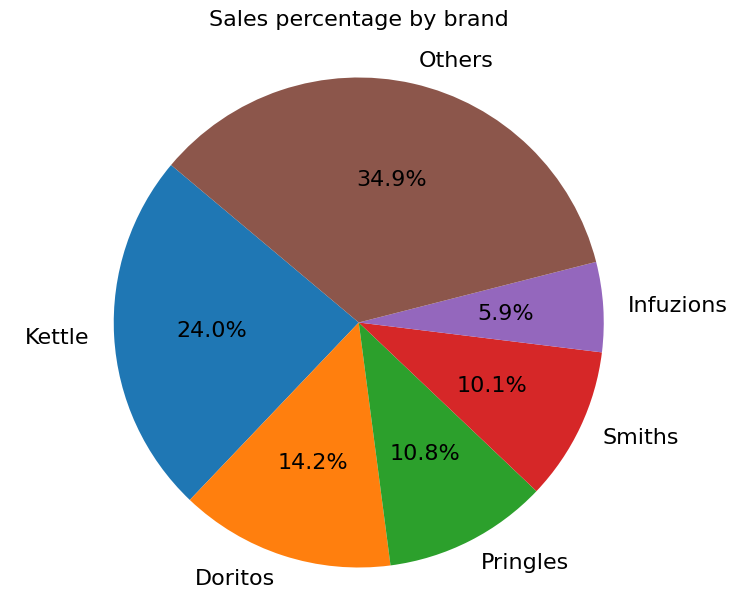

In [85]:
# Plot Pie Chart
plt.figure(figsize=(9, 7))
plt.pie(
    compare_brand['TOT_SALES'], 
    labels=compare_brand['BRAND'], 
    autopct='%1.1f%%', 
    startangle=140, 
    textprops={'fontsize':16}
)

plt.title('Sales percentage by brand', fontsize=16, pad=20)
plt.axis('equal')  
plt.show()

The brand with most sales is Kettle

In [ ]:
# Apriori analysis for brands bought by YOUNG SINGLES/COUPLES who are Mainstream
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

transactions = data.groupby('LYLTY_CARD_NBR')['BRAND'].apply(list).tolist()

te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)
basket = pd.DataFrame(te_array, columns=te.columns_)

frequent_itemsets = apriori(basket, min_support=0.01, use_colnames=True)
#frequent_itemsets[frequent_itemsets['itemsets'].apply(lambda x: len(x) > 1)]

rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1)
rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].sort_values(by='lift', ascending=False).head(10)


,antecedents,consequents,support,confidence,lift
1120,"(Smiths, Woolworths)","(RRD, Pringles)",0.010353,0.148730,2.884260
1125,"(RRD, Pringles)","(Smiths, Woolworths)",0.010353,0.200762,2.884260
1041,"(Doritos, RRD)","(Smiths, Woolworths)",0.010521,0.200588,2.881770
1036,"(Smiths, Woolworths)","(Doritos, RRD)",0.010521,0.151149,2.881770
1039,"(Doritos, Woolworths)","(Smiths, RRD)",0.010521,0.259336,2.871589
1038,"(Smiths, RRD)","(Doritos, Woolworths)",0.010521,0.116496,2.871589
1124,"(Woolworths, Pringles)","(Smiths, RRD)",0.010353,0.254132,2.813968
1121,"(Smiths, RRD)","(Woolworths, Pringles)",0.010353,0.114632,2.813968
1108,"(Kettle, RRD)","(Smiths, Woolworths)",0.014407,0.195099,2.802903
1109,"(Smiths, Woolworths)","(Kettle, RRD)",0.014407,0.206973,2.802903


### Total Sales of each pack size

In [ ]:
# Total sales of each PACK_SIZE
size_sales = selected_segment.groupby('PACK_SIZE')['TOT_SALES'].sum().sort_values(ascending=False).reset_index()
size_sales

,PACK_SIZE,TOT_SALES
0,175.0,37967.9
1,150.0,22946.2
2,134.0,16006.2
3,110.0,14630.0
4,330.0,12654.0
5,170.0,11893.4
6,165.0,7395.0
7,380.0,7175.9
8,270.0,5303.8
9,210.0,3798.0


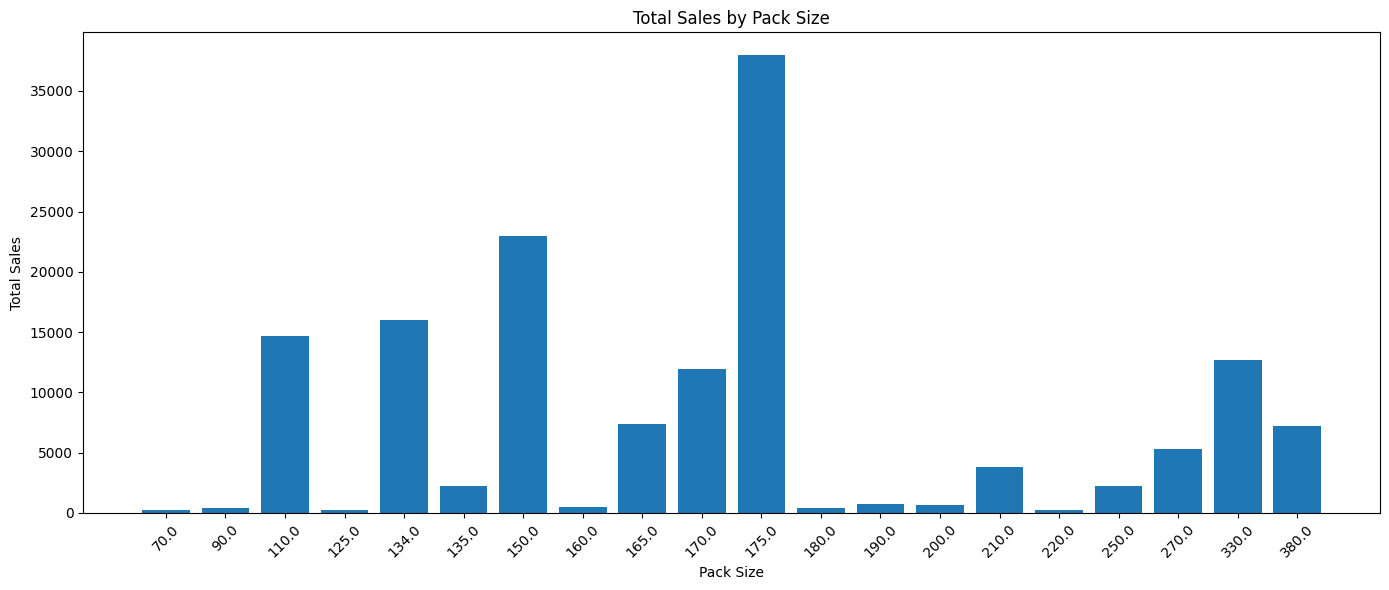

In [ ]:
# Total Sales by PACK_SIZE
size_sales = selected_segment.groupby('PACK_SIZE')['TOT_SALES'].sum().reset_index()
size_sales = size_sales.sort_values(by='PACK_SIZE')

x = size_sales['PACK_SIZE'].astype(str)
y = size_sales['TOT_SALES']

plt.figure(figsize=(14, 6))
plt.bar(x, y)
plt.xlabel('Pack Size')
plt.ylabel('Total Sales')
plt.title('Total Sales by Pack Size')
plt.xticks(ticks=range(len(x)), labels=x, rotation=45)
plt.tight_layout()
plt.show()

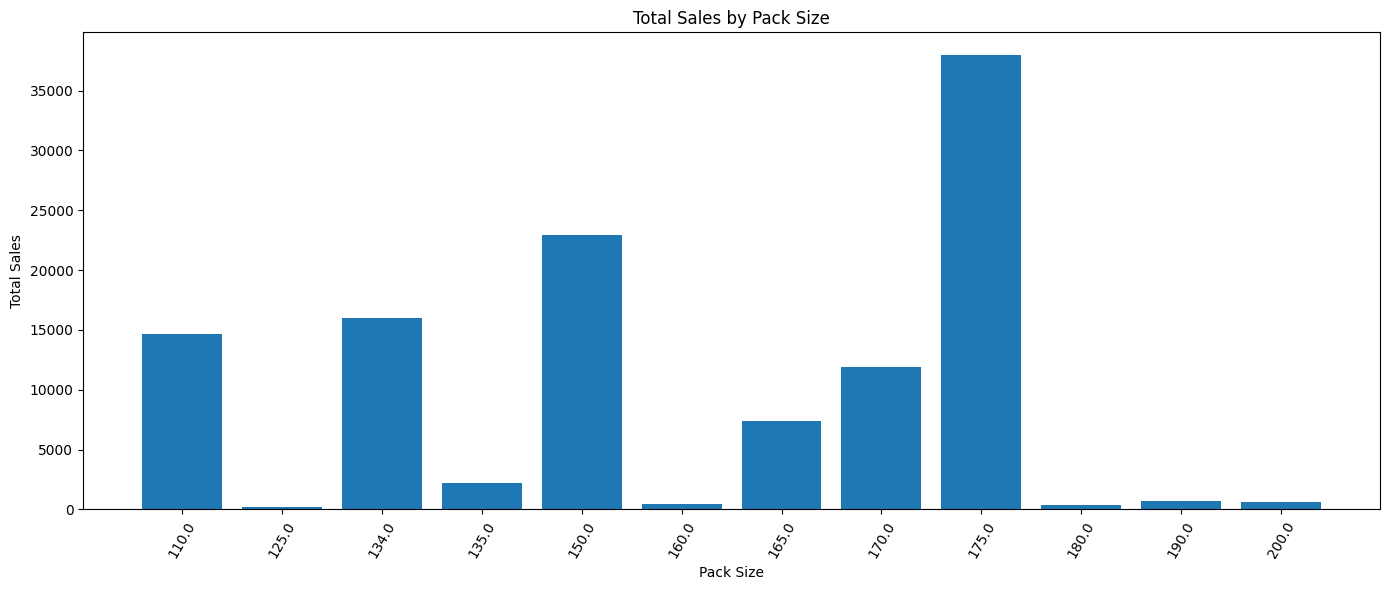

In [ ]:
# Total Sales by PACK_SIZE (from 100g - 200g)
focused_size = size_sales[
    (size_sales['PACK_SIZE'] >= 100) &
    (size_sales['PACK_SIZE'] <= 200)
].sort_values(by='PACK_SIZE')

x = focused_size['PACK_SIZE'].astype(str)
y = focused_size['TOT_SALES']

plt.figure(figsize=(14, 6))
plt.bar(x, y)
plt.xlabel('Pack Size')
plt.ylabel('Total Sales')
plt.title('Total Sales by Pack Size')
plt.xticks(ticks=range(len(x)), labels=x, rotation=60, fontsize=10)

plt.tight_layout()
plt.show()
